In [1]:
TRAIN_LOG = '../logs/PEA_STA/train-walk-300.log'

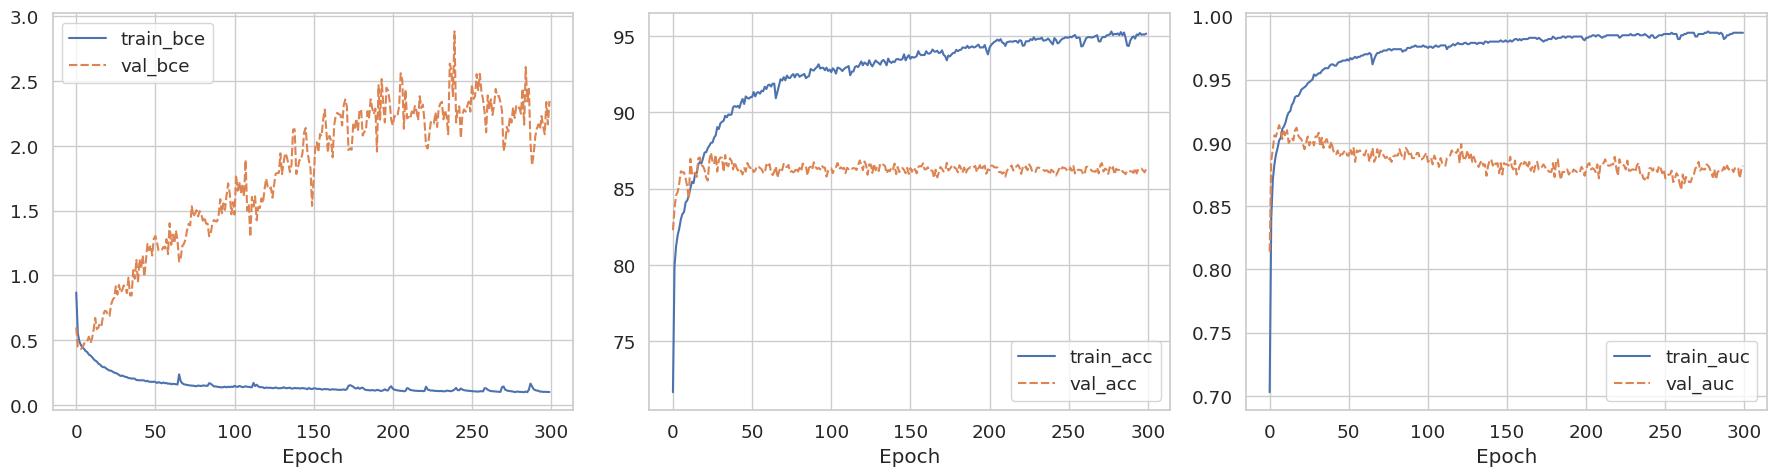

In [2]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- 1. 正则 ----------
pattern = re.compile(
    r"\[ Epoch (\d+) of \d+ \].*?"
    r"\(Training\)\s+bce:\s+([\d\.]+).*?acc:\s+([\d\.]+) %.*?auc:\s+([\d\.]+).*?"
    r"\(Validation-hyper\).*?bce:\s+([\d\.]+).*?acc:\s+([\d\.]+) %.*?auc:\s+([\d\.]+)",
    re.DOTALL
)

# ---------- 2. 解析日志文件 ----------
with open(TRAIN_LOG, "r", encoding="utf-8") as f:
    log = f.read()

data = []
for m in pattern.finditer(log):
    epoch, tr_bce, tr_acc, tr_auc, val_bce, val_acc, val_auc = m.groups()
    data.append({
        "epoch": int(epoch),
        "train_bce": float(tr_bce),
        "train_acc": float(tr_acc),
        "train_auc": float(tr_auc),
        "val_bce": float(val_bce),
        "val_acc": float(val_acc),
        "val_auc": float(val_auc),
    })

df = pd.DataFrame(data)
df.set_index("epoch", inplace=True)

# ---------- 3. 可视化 ----------
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["bce", "acc", "auc"]
for ax, m in zip(axes, metrics):
    sns.lineplot(data=df[["train_" + m, "val_" + m]], ax=ax)
    ax.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("train_val_curves.png", dpi=300)
plt.show()